6. Model evaluation

Evaluate the saved model on untouched data and save figures, metrics, and prediction records.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
MODEL, HOLD = ROOT/'models/overdue_risk_model.joblib', ROOT/'models/evaluation_holdout.joblib'
FIG, MET, PRED = ROOT/'figures/modeling', ROOT/'results/metrics', ROOT/'results/predictions'
for p in (FIG,MET,PRED): p.mkdir(parents=True, exist_ok=True)
model, hold = joblib.load(MODEL), joblib.load(HOLD)
X_test, y_test = hold['X_test'], hold['y_test']
prob = model.predict_proba(X_test)[:,1]; pred = model.predict(X_test)
pd.DataFrame(classification_report(y_test,pred,output_dict=True)).T.to_csv(MET/'holdout_classification_report.csv')
pd.DataFrame({'roc_auc':[roc_auc_score(y_test,prob)]}).to_csv(MET/'holdout_summary.csv',index=False)


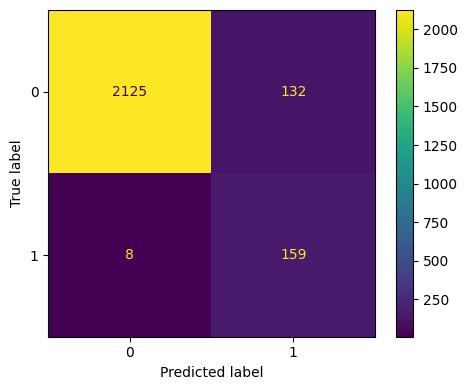

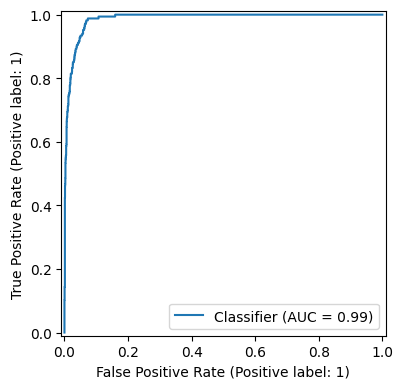

In [2]:
fig,ax=plt.subplots(figsize=(5,4)); ConfusionMatrixDisplay.from_predictions(y_test,pred,ax=ax); fig.tight_layout(); fig.savefig(FIG/'confusion_matrix.png',dpi=160)
fig,ax=plt.subplots(figsize=(5,4)); RocCurveDisplay.from_predictions(y_test,prob,ax=ax); fig.tight_layout(); fig.savefig(FIG/'roc_curve.png',dpi=160)
predictions=X_test.copy(); predictions['actual_overdue']=y_test; predictions['overdue_risk_probability']=prob; predictions.to_csv(PRED/'holdout_predictions.csv',index=False)
